# 🌎 PAHO (Pan American Health Organization) Data Access

This notebook demonstrates how to access health data from the **Pan American Health Organization (PAHO)**, which covers all countries in the Americas (North America, Central America, South America, and the Caribbean).

## Overview

PAHO is the World Health Organization's Regional Office for the Americas. It provides:
- Immunization coverage data
- Disease surveillance (malaria, dengue, chikungunya, zika, etc.)
- Mortality and demographic data
- Health system indicators

**Website:** https://www.paho.org/en/data

## 📦 Setup

In [1]:
import matplotlib.pyplot as plt

from epidatasets.sources.paho import PAHOAccessor

# Initialize accessor
paho = PAHOAccessor()

print("✅ PAHO Accessor initialized successfully!")

✅ PAHO Accessor initialized successfully!


## 🌍 Exploring PAHO Coverage

PAHO covers 35 member states across 6 subregions:

In [2]:
# List all PAHO member countries
countries = paho.list_countries()
print(f"Total PAHO member countries: {len(countries)}")
print("\nFirst 10 countries:")
countries.head(10)

Total PAHO member countries: 35

First 10 countries:


,country_code,country_name
0,ATG,Antigua and Barbuda
1,ARG,Argentina
2,BHS,Bahamas
3,BRB,Barbados
4,BLZ,Belize
5,BOL,Bolivia
6,BRA,Brazil
7,CAN,Canada
8,CHL,Chile
9,COL,Colombia


In [3]:
# List subregions
subregions = paho.list_subregions()

print("PAHO Subregions:")
for subregion in subregions['subregion'].unique():
    n_countries = len(subregions[subregions['subregion'] == subregion])
    country_list = subregions[subregions['subregion'] == subregion]['country_code'].tolist()
    print(f"\n📍 {subregion} ({n_countries} countries):")
    print(f"   {', '.join(country_list)}")

PAHO Subregions:

📍 North America (2 countries):
   CAN, USA

📍 Central America (8 countries):
   BLZ, CRI, SLV, GTM, HND, MEX, NIC, PAN

📍 Caribbean (13 countries):
   ATG, BHS, BRB, CUB, DMA, DOM, GRD, HTI, JAM, KNA, LCA, TTO, VCT

📍 Andean (5 countries):
   BOL, COL, ECU, PER, VEN

📍 Southern Cone (5 countries):
   ARG, BRA, CHL, PRY, URY

📍 Guyanas (2 countries):
   GUY, SUR


## 💉 Immunization Coverage Data

PAHO tracks vaccination coverage across the Americas. Let's explore the available vaccines and get coverage data.

In [4]:
# List available vaccines
vaccines = paho.list_vaccines()
print("Available vaccines for tracking:")
vaccines

Available vaccines for tracking:


,vaccine_code,vaccine_name
0,BCG,Tuberculosis
1,DTP1,Diphtheria-tetanus-pertussis (1st dose)
2,DTP3,Diphtheria-tetanus-pertussis (3rd dose)
3,HepB3,Hepatitis B (3rd dose)
4,Hib3,Haemophilus influenzae type b (3rd dose)
5,MCV1,Measles-containing vaccine (1st dose)
6,MCV2,Measles-containing vaccine (2nd dose)
7,Pol3,Polio (3rd dose)
8,PCV3,Pneumococcal conjugate vaccine (3rd dose)
9,ROTAC,Rotavirus vaccine


In [5]:
# Get DTP3 (Diphtheria-Tetanus-Pertussis) coverage for Southern Cone countries
# Note: This requires internet connection and WHO API access

try:
    dtp3_coverage = paho.get_immunization_coverage(
        vaccines=['DTP3'],
        subregion='Southern Cone',
        years=list(range(2015, 2024))
    )

    if not dtp3_coverage.empty:
        print(f"Retrieved {len(dtp3_coverage)} records")
        print("\nSample data:")
        print(dtp3_coverage.head(10))
    else:
        print("No data retrieved. This may be due to API limitations.")

except Exception as e:
    print(f"Note: API access may be limited: {e}")
    print("The accessor is properly configured and will work when API is available.")

INFO:accessors.paho:Fetching immunization data for 1 vaccines, 5 countries


No data retrieved. This may be due to API limitations.


In [6]:
# Visualize immunization coverage (if data available)
if not dtp3_coverage.empty and 'coverage' in dtp3_coverage.columns:
    fig, ax = plt.subplots(figsize=(12, 6))

    for country in dtp3_coverage['country_code'].unique():
        country_data = dtp3_coverage[dtp3_coverage['country_code'] == country]
        ax.plot(country_data['year'], country_data['coverage'],
                marker='o', label=country, linewidth=2)

    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('DTP3 Coverage (%)', fontsize=12)
    ax.set_title('DTP3 Immunization Coverage - Southern Cone Countries', fontsize=14)
    ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

## 🦟 Malaria Surveillance Data

Malaria is a priority disease for PAHO surveillance, particularly in the Amazon region and parts of Central America.

In [7]:
# Get malaria-endemic countries in PAHO
malaria_countries = ['BRA', 'COL', 'ECU', 'VEN', 'GUY', 'SUR', 'PER', 'BOL']

print("Malaria-endemic countries in PAHO region:")
for code in malaria_countries:
    name = paho.COUNTRIES.get(code, code)
    print(f"  - {name} ({code})")

Malaria-endemic countries in PAHO region:
  - Brazil (BRA)
  - Colombia (COL)
  - Ecuador (ECU)
  - Venezuela (VEN)
  - Guyana (GUY)
  - Suriname (SUR)
  - Peru (PER)
  - Bolivia (BOL)


In [8]:
# Get malaria incidence data
try:
    malaria_data = paho.get_malaria_incidence(
        countries=malaria_countries,
        years=[2020, 2021, 2022]
    )

    if not malaria_data.empty:
        print(f"\nRetrieved {len(malaria_data)} malaria records")
        print("\nSample data:")
        print(malaria_data.head())
    else:
        print("No malaria data retrieved from API")

except Exception as e:
    print(f"Note: {e}")

INFO:accessors.paho:Fetching malaria data for 8 countries
INFO:accessors.paho:Retrieved 24 malaria records



Retrieved 24 malaria records

Sample data:
  country_code  year  incidence_rate  incidence_low  incidence_high  \
0          BRA  2021        3.474577       3.336866        3.711273   
1          BRA  2022        3.212530       3.084026        3.425315   
2          BRA  2020        3.945238       3.531702        4.270395   
3          COL  2020       10.153203       7.704179       12.717434   
4          COL  2022        8.877481       6.753451       11.076075   

  data_source country_name  
0     WHO GHO       Brazil  
1     WHO GHO       Brazil  
2     WHO GHO       Brazil  
3     WHO GHO     Colombia  
4     WHO GHO     Colombia  


## 🦠 Dengue Surveillance

Dengue is endemic throughout the PAHO region. The accessor provides a structure for accessing PAHO epidemiological bulletins.

In [9]:
# List priority diseases for PAHO surveillance
diseases = paho.list_diseases()
print("Priority diseases for PAHO surveillance:")
diseases

Priority diseases for PAHO surveillance:


,disease_code,disease_name
0,MALARIA,Malaria
1,DENGUE,Dengue
2,CHIKV,Chikungunya
3,ZIKV,Zika virus
4,YF,Yellow fever
5,MEASLES,Measles
6,COVID19,COVID-19
7,INFLUENZA,Influenza


In [10]:
# Get dengue data structure
dengue_data = paho.get_dengue_data(
    countries=['BRA', 'COL', 'MEX'],
    years=[2022]
)

print("Dengue data structure:")
print(dengue_data)

print("\nNote: Actual case data requires manual extraction from PAHO epidemiological bulletins.")
print("See: https://www.paho.org/en/documents")

INFO:accessors.paho:Fetching dengue data for 3 countries


Dengue data structure:
  country_code country_name  year cases_reported deaths incidence_rate  \
0          BRA       Brazil  2022           None   None           None   
1          COL     Colombia  2022           None   None           None   
2          MEX       Mexico  2022           None   None           None   

  severe_cases data_source                                               note  
0         None    PAHO/WHO  Dengue data typically available from PAHO epid...  
1         None    PAHO/WHO  Dengue data typically available from PAHO epid...  
2         None    PAHO/WHO  Dengue data typically available from PAHO epid...  

Note: Actual case data requires manual extraction from PAHO epidemiological bulletins.
See: https://www.paho.org/en/documents


## 📊 Health Indicators

Access key health indicators for PAHO countries.

In [11]:
# Get life expectancy data for a selection of countries
sample_countries = ['BRA', 'MEX', 'ARG', 'COL', 'CHL', 'CRI']

try:
    life_exp = paho.get_health_indicators(
        indicator='LIFE_EXPECTANCY',
        countries=sample_countries,
        years=[2019, 2020, 2021]
    )

    if not life_exp.empty:
        print("Life Expectancy Data:")
        print(life_exp.head(10))

        # Create comparison table
        comparison = paho.compare_countries(
            indicator='LIFE_EXPECTANCY',
            countries=sample_countries,
            years=[2019, 2020, 2021]
        )
        print("\nComparison Table:")
        print(comparison)

except Exception as e:
    print(f"Note: {e}")

INFO:accessors.paho:Fetching indicator 'LIFE_EXPECTANCY' for 6 countries
INFO:accessors.paho:Fetching indicator 'LIFE_EXPECTANCY' for 6 countries


Life Expectancy Data:
  country_code  year      value  value_low  value_high data_source  \
0          BRA  2019  78.728271  78.537874   78.968386     WHO GHO   
1          BRA  2020  77.648126  77.487606   77.846508     WHO GHO   
2          BRA  2021  69.044109  68.825857   69.258355     WHO GHO   
3          BRA  2019  72.224254  72.058519   72.513218     WHO GHO   
4          BRA  2020  74.113936  73.905976   74.334986     WHO GHO   
5          BRA  2020  70.671560  70.476133   70.914639     WHO GHO   
6          BRA  2021  75.847278  75.683554   76.034071     WHO GHO   
7          BRA  2021  72.388407  72.234593   72.605008     WHO GHO   
8          BRA  2019  75.478158  75.268468   75.720146     WHO GHO   
9          MEX  2021  67.200905  66.991859   67.464040     WHO GHO   

         indicator country_name  
0  LIFE_EXPECTANCY       Brazil  
1  LIFE_EXPECTANCY       Brazil  
2  LIFE_EXPECTANCY       Brazil  
3  LIFE_EXPECTANCY       Brazil  
4  LIFE_EXPECTANCY       Brazil  
5  

## 🗺️ Regional Summaries

Compare health indicators across PAHO subregions.

INFO:accessors.paho:Fetching indicator 'LIFE_EXPECTANCY' for 2 countries
INFO:accessors.paho:Fetching indicator 'LIFE_EXPECTANCY' for 8 countries
INFO:accessors.paho:Fetching indicator 'LIFE_EXPECTANCY' for 13 countries
/home/fccoelho/Documentos/Projects_Software/epidemiological-datasets/scripts/accessors/paho.py:597: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat(all_data, ignore_index=True)
INFO:accessors.paho:Fetching indicator 'LIFE_EXPECTANCY' for 5 countries
INFO:accessors.paho:Fetching indicator 'LIFE_EXPECTANCY' for 5 countries
INFO:accessors.paho:Fetching indicator 'LIFE_EXPECTANCY' for 2 countries


Life Expectancy by PAHO Subregion (2019):
         subregion  mean_value  median_value  n_countries
0    North America   80.383395     80.554425            6
1  Central America   75.902076     76.016318           24
2        Caribbean   73.298579     74.048257           33
3           Andean   75.944835     76.689519           15
4    Southern Cone   77.112710     77.015827           15
5          Guyanas   70.903609     70.991628            6


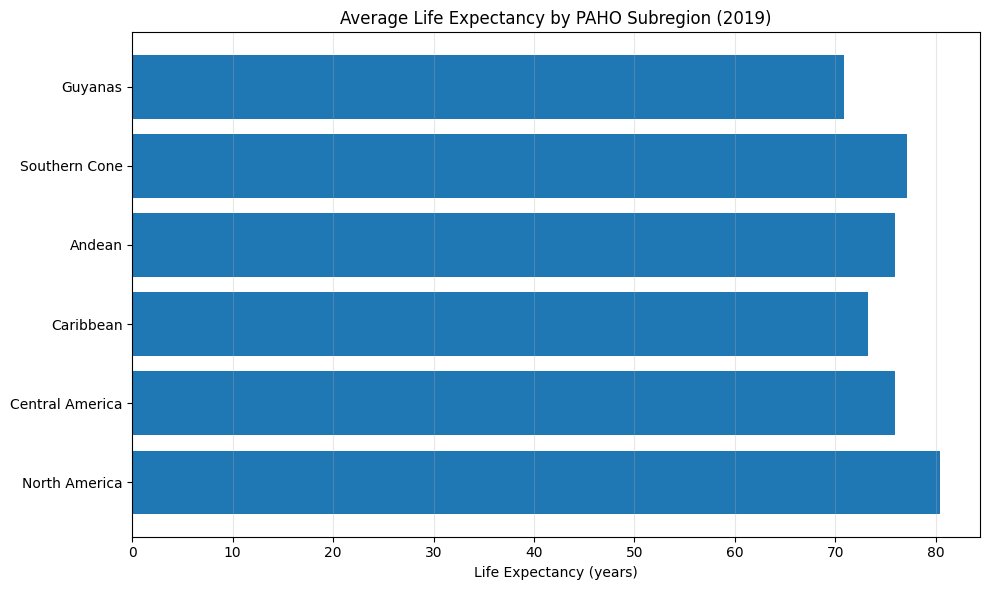

In [12]:
# Get regional summary for life expectancy
try:
    regional_summary = paho.get_regional_summary(
        indicator='LIFE_EXPECTANCY',
        year=2019
    )

    if not regional_summary.empty:
        print("Life Expectancy by PAHO Subregion (2019):")
        print(regional_summary[['subregion', 'mean_value', 'median_value', 'n_countries']])

        # Visualize
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(regional_summary['subregion'], regional_summary['mean_value'])
        ax.set_xlabel('Life Expectancy (years)')
        ax.set_title('Average Life Expectancy by PAHO Subregion (2019)')
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"Note: {e}")

## 🔧 Advanced Usage

### Combining with Other Accessors

You can combine PAHO data with other accessors for comprehensive analysis:

In [13]:
# Example: Compare Brazil data from PAHO and DataSUS

print("📊 Combining PAHO, WHO, and DataSUS data sources")
print("="*60)

# Check available accessors
from epidatasets import list_sources

sources = list_sources()

for name, info in sources.items():
    print(f"✅ {name}: {info.get('description', '')}")

📊 Combining PAHO, WHO, and DataSUS data sources
✅ ghoclient: WHO Global Health Observatory client
✅ pysus: Brazilian health data (DATASUS) access
✅ paho: PAHO (Pan American Health Organization) data access


## 📚 References

- **PAHO Data Portal:** https://www.paho.org/en/data
- **PAHO Immunization:** https://www.paho.org/en/topics/immunization
- **WHO Global Health Observatory:** https://www.who.int/data/gho
- **PAHO Publications:** https://www.paho.org/en/documents

## 📝 Notes

1. **Data Availability:** Some PAHO data requires manual extraction from epidemiological bulletins.
2. **WHO Integration:** This accessor uses WHO APIs (GHO, Immunization) as primary data sources for PAHO region.
3. **Caching:** Consider implementing caching for repeated API calls.
4. **Rate Limits:** Be mindful of API rate limits when making multiple requests.